# EDA 05 — Merged Analytical Dataset of Road closures and train moments

**Source**: Output of `geo.find_nearby_stations()` + `features.filter_within_time_window()`  
**Reads from**: `data/processed/road_closures_clean.parquet` + `data/processed/train_moments_clean.parquet`  
**Output**: `data/processed/road_train_moments_dataset.parquet`  consumed by `rail_delay_prediction.ipynb`

This notebook performs EDA on the merged analytical dataset that results from the spatial join (10-25 km haversine) and temporal filter (0-60 minute post-closure window). This is the dataset the model trains on. Exploring it here keeps the main analysis notebook focused purely on modelling.

---
**Sections**
1. Rebuild the analytical dataset from processed parquets  
2. Dataset overview and shape  
3. Delay (target variable) distribution  
4. Predictor distributions (distance, time)  
5. Categorical distributions (closure type, event type)  
6. Bivariate relationships (scatter, heatmap, correlation)  
7. Temporal patterns (hour of day, day of week)  
8. Spatial patterns (stations, closure impact)  
9. Save output  


## 0. Setup

In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, "..")
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", 40)
os.makedirs("figures/eda_05", exist_ok=True)
os.makedirs("./data/processed", exist_ok=True)
%matplotlib inline

## 1. Rebuild Analytical Dataset

Rather than re-downloading from Azure, read the processed parquet files saved by EDA 02 and EDA 03, then re-run the spatial join and temporal filter. This keeps the EDA self-contained and fast.

In [2]:
from datetime import datetime, timezone
from src.geo import find_nearby_stations
from src.features import (
    merge_on_station, filter_within_time_window,
    reshape_timetable_to_schedule, merge_schedule_with_closures
)

# Load from processed parquets where available, else re-fetch
import os
stations_reference_path = "./data/processed/stations_reference.parquet"
road_path  = "./data/processed/road_closures_clean.parquet"
train_path = "./data/processed/train_moments_clean.parquet"

if os.path.exists(road_path) and os.path.exists(train_path):
    road_df  = pd.read_parquet(road_path)
    train_df = pd.read_parquet(train_path)
    stations_ref_df = pd.read_parquet(stations_reference_path)
    print(f"Loaded from parquet: {len(road_df):,} closures, {len(train_df):,} train moments, {len(stations_ref_df):,} stations")
else:
    print("Processed parquets not found — run EDA 01 and EDA 02 first.")
    raise FileNotFoundError("Missing processed parquets")

Loaded from parquet: 296 closures, 78,821 train moments, 2,594 stations


In [3]:
# Spatial join
expanded_road_df = find_nearby_stations(road_df, stations_ref_df, min_km=10, max_km=25)
print(f"Closure-station pairs: {len(expanded_road_df):,}")

Closure-station pairs: 16,361


In [4]:
# Merge with train moments
merged_df = merge_on_station(expanded_road_df, train_df)
print(f"After merge: {len(merged_df):,} rows")

# Temporal filter: 0-60 minutes post-closure
filtered_df = filter_within_time_window(merged_df, window_minutes=60)
print(f"After 60-min filter: {len(filtered_df):,} rows")

# Select final columns
keep_cols = [
    "closure_id", "closure_type", "closure_lat", "closure_lon",
    "validity_status", "cause_type",
    "distance_in_km", "station_name", "stanox",
    "closure_start_time", "actual_timestamp", "planned_timestamp",
    "planned_time_diff", "event_type",
    "start_hour","start_dow","duration_hours"
]
filtered_df = filtered_df[[c for c in keep_cols if c in filtered_df.columns]].copy()

# Compute delay
filtered_df["actual_timestamp"]  = pd.to_datetime(filtered_df["actual_timestamp"])
filtered_df["planned_timestamp"] = pd.to_datetime(filtered_df["planned_timestamp"])
filtered_df["delay"] = (
    filtered_df["actual_timestamp"] - filtered_df["planned_timestamp"]
).dt.total_seconds() / 60

# Interaction feature
filtered_df["distance_time_interaction"] = (
    filtered_df["distance_in_km"] * filtered_df["planned_time_diff"]
)

print(f"\nFinal analytical dataset: {len(filtered_df):,} rows")
filtered_df.head()

After merge: 549,013 rows
After 60-min filter: 5,468 rows

Final analytical dataset: 5,468 rows


,closure_id,closure_type,closure_lat,closure_lon,validity_status,cause_type,distance_in_km,station_name,stanox,closure_start_time,actual_timestamp,planned_timestamp,planned_time_diff,event_type,start_hour,start_dow,delay,distance_time_interaction
1382,483341,planned,51.362305,-2.889965,planned,constructionWork,22.269165,Bedminster,81813,2026-04-10 19:00:00,2026-04-10 19:56:00,2026-04-10 19:55:30,55.5,ARRIVAL,19.0,4.0,0.5,1235.938657
1462,483341,planned,51.362305,-2.889965,planned,constructionWork,22.435264,Cardiff Bay,78456,2026-04-10 19:00:00,2026-04-10 19:59:00,2026-04-10 19:53:00,53.0,ARRIVAL,19.0,4.0,6.0,1189.069015
1510,483341,planned,51.362305,-2.889965,planned,constructionWork,23.716110,Cardiff Central,77301,2026-04-10 19:00:00,2026-04-10 19:28:00,2026-04-10 19:28:00,28.0,DEPARTURE,19.0,4.0,0.0,664.051071
1511,483341,planned,51.362305,-2.889965,planned,constructionWork,23.716110,Cardiff Central,77301,2026-04-10 19:00:00,2026-04-10 19:46:00,2026-04-10 19:27:00,27.0,ARRIVAL,19.0,4.0,19.0,640.334961
1513,483341,planned,51.362305,-2.889965,planned,constructionWork,23.716110,Cardiff Central,77301,2026-04-10 19:00:00,2026-04-10 19:53:00,2026-04-10 19:56:00,56.0,DEPARTURE,19.0,4.0,-3.0,1328.102142


## 2. Dataset Overview

In [5]:
filtered_df.info()

<class 'pandas.DataFrame'>
Index: 5468 entries, 1382 to 539622
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   closure_id                 5468 non-null   str           
 1   closure_type               5468 non-null   str           
 2   closure_lat                5468 non-null   float64       
 3   closure_lon                5468 non-null   float64       
 4   validity_status            5468 non-null   str           
 5   cause_type                 5468 non-null   str           
 6   distance_in_km             5468 non-null   float64       
 7   station_name               5468 non-null   str           
 8   stanox                     5468 non-null   str           
 9   closure_start_time         5468 non-null   datetime64[us]
 10  actual_timestamp           5468 non-null   datetime64[ms]
 11  planned_timestamp          5468 non-null   datetime64[ms]
 12  planned_time_diff

In [6]:
print("=" * 70)
print("DATASET SUMMARY")
print("=" * 70)
print(f"Total rows:             {len(filtered_df):,}")
print(f"Unique stations:        {filtered_df['station_name'].nunique():,}")
print(f"Unique closures:        {filtered_df['closure_id'].nunique():,}")
print(f"Date range (planned):   {filtered_df['planned_timestamp'].min()} — {filtered_df['planned_timestamp'].max()}")
print()
print("By closure type:")
print(filtered_df["closure_type"].value_counts().to_string())
print()
print("By event type:")
print(filtered_df["event_type"].value_counts().to_string())

DATASET SUMMARY
Total rows:             5,468
Unique stations:        848
Unique closures:        125
Date range (planned):   2026-04-09 21:56:30 — 2026-04-12 22:59:00

By closure type:
closure_type
unplanned    3054
planned      2414

By event type:
event_type
DEPARTURE    2783
ARRIVAL      2685


## 3. Delay (Target Variable) Distribution

In [7]:
delay = filtered_df["delay"]
print("Delay statistics (minutes):")
print(delay.describe().round(3))
print(f"\nSkewness: {delay.skew():.4f}")
print(f"Kurtosis: {delay.kurtosis():.4f}")
print()
print("Quantiles:")
print(delay.quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(2))

Delay statistics (minutes):
count    5468.000
mean        1.014
std         5.757
min      -104.000
25%        -0.500
50%         0.000
75%         1.500
max        61.500
Name: delay, dtype: float64

Skewness: -2.3696
Kurtosis: 84.2556

Quantiles:
0.01   -11.33
0.05    -1.50
0.25    -0.50
0.50     0.00
0.75     1.50
0.95     8.50
0.99    22.00
Name: delay, dtype: float64


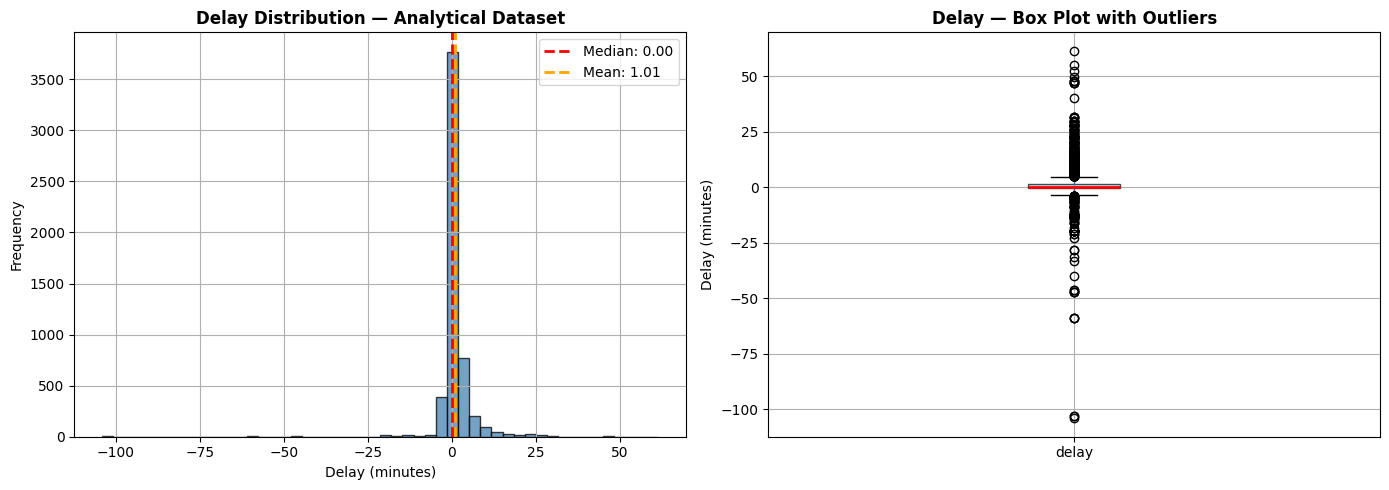

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

delay.hist(bins=50, ax=axes[0], edgecolor="black", alpha=0.75, color="steelblue")
axes[0].axvline(delay.median(), color="red", linestyle="--", lw=2,
                label=f"Median: {delay.median():.2f}")
axes[0].axvline(delay.mean(), color="orange", linestyle="--", lw=2,
                label=f"Mean: {delay.mean():.2f}")
axes[0].set_xlabel("Delay (minutes)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Delay Distribution — Analytical Dataset", fontweight="bold")
axes[0].legend()

filtered_df.boxplot(column="delay", vert=True, ax=axes[1], patch_artist=True,
                    boxprops=dict(facecolor="lightblue", alpha=0.7),
                    medianprops=dict(color="red", linewidth=2))
axes[1].set_ylabel("Delay (minutes)")
axes[1].set_title("Delay — Box Plot with Outliers", fontweight="bold")

plt.tight_layout()
plt.savefig("figures/eda_05/delay_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

In [9]:
# Outlier investigation
extreme_early = filtered_df[filtered_df["delay"] < -30]
extreme_late  = filtered_df[filtered_df["delay"] > 30]
print(f"Extreme early (< -30 min): {len(extreme_early):,} ({len(extreme_early)/len(filtered_df)*100:.2f}%)")
print(f"Extreme late  (> 30 min):  {len(extreme_late):,} ({len(extreme_late)/len(filtered_df)*100:.2f}%)")
if len(extreme_late):
    print("\nSample extreme late records:")
    display(extreme_late[["station_name","planned_timestamp","actual_timestamp","delay","closure_type"]].head(10))

Extreme early (< -30 min): 14 (0.26%)
Extreme late  (> 30 min):  15 (0.27%)

Sample extreme late records:


,station_name,planned_timestamp,actual_timestamp,delay,closure_type
1514,Cardiff Central,2026-04-10 19:25:00,2026-04-10 20:05:00,40.0,planned
151870,Shortlands,2026-04-12 21:30:30,2026-04-12 22:23:00,52.5,planned
161199,Kirk Sandall,2026-04-12 19:31:30,2026-04-12 20:03:00,31.5,planned
161764,Kirk Sandall,2026-04-12 19:31:30,2026-04-12 20:03:00,31.5,planned
162323,Kirk Sandall,2026-04-12 19:31:30,2026-04-12 20:03:00,31.5,planned
177710,Victoria,2026-04-10 22:03:00,2026-04-10 22:50:00,47.0,planned
195010,Harrow and Wealdstone,2026-04-12 22:36:00,2026-04-12 23:31:00,55.0,planned
223481,Victoria,2026-04-10 22:03:00,2026-04-10 22:50:00,47.0,planned
283703,Battersea Park,2026-04-10 23:17:30,2026-04-11 00:19:00,61.5,unplanned
283704,Battersea Park,2026-04-10 23:32:30,2026-04-11 00:22:00,49.5,unplanned


## 4. Predictor Distributions

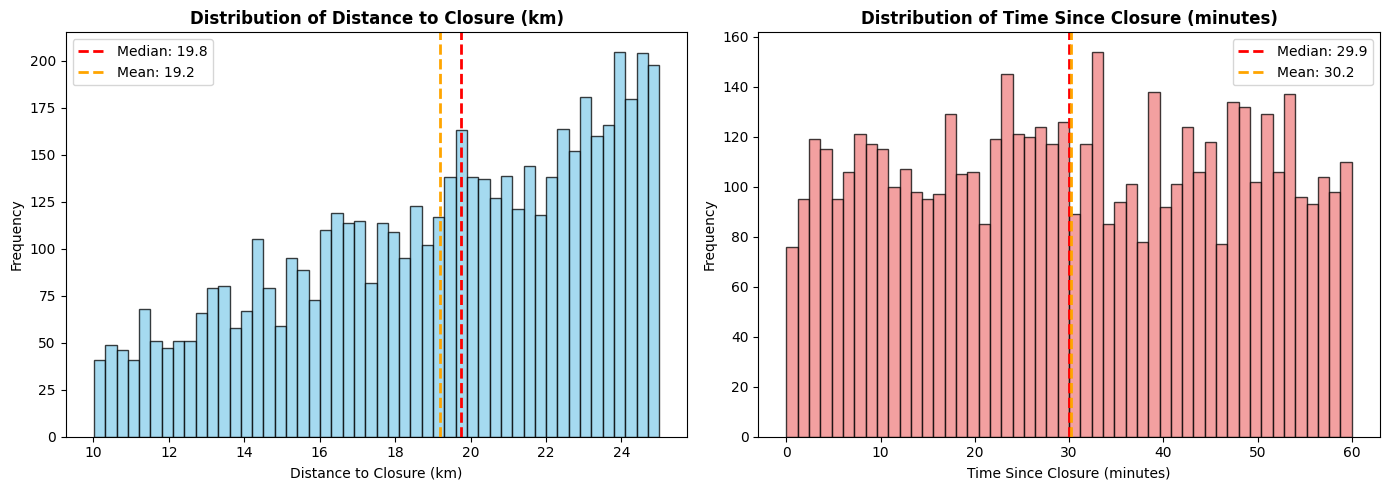

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, color, label in [
    (axes[0], "distance_in_km", "skyblue", "Distance to Closure (km)"),
    (axes[1], "planned_time_diff", "lightcoral", "Time Since Closure (minutes)")
]:
    s = filtered_df[col]
    ax.hist(s, bins=50, edgecolor="black", alpha=0.75, color=color)
    ax.axvline(s.median(), color="red", linestyle="--", lw=2, label=f"Median: {s.median():.1f}")
    ax.axvline(s.mean(), color="orange", linestyle="--", lw=2, label=f"Mean: {s.mean():.1f}")
    ax.set_xlabel(label)
    ax.set_ylabel("Frequency")
    ax.set_title(f"Distribution of {label}", fontweight="bold")
    ax.legend()
plt.tight_layout()
plt.savefig("figures/eda_05/predictor_distributions.png", dpi=200, bbox_inches="tight")
plt.show()

## 5. Categorical Distributions

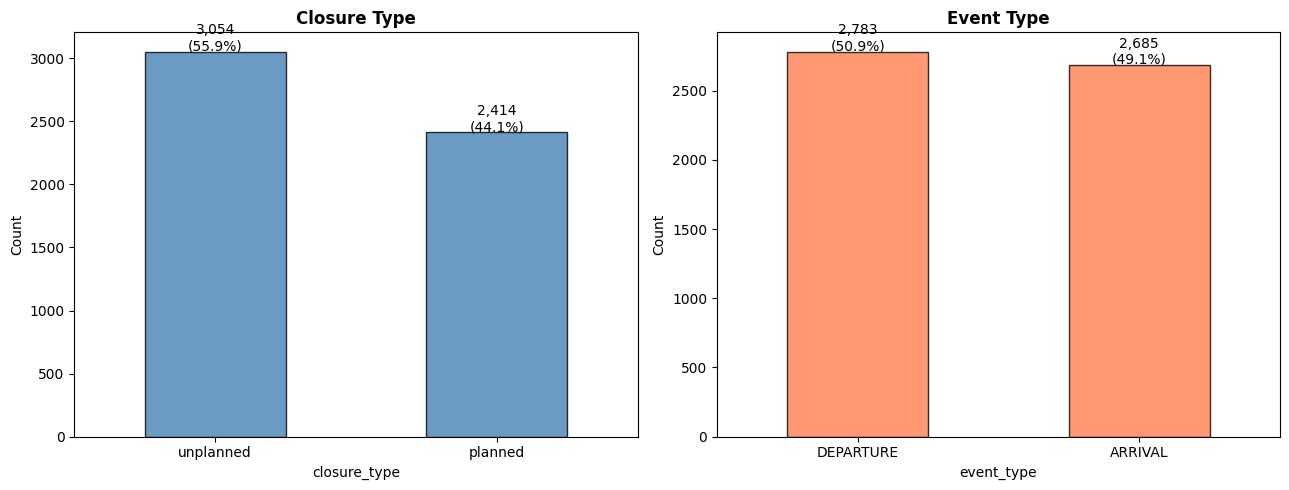

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ct = filtered_df["closure_type"].value_counts()
ct.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black", alpha=0.8)
axes[0].set_title("Closure Type", fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)
for i, v in enumerate(ct.values):
    axes[0].text(i, v + 10, f"{v:,}\n({v/len(filtered_df)*100:.1f}%)", ha="center", fontsize=10)

et = filtered_df["event_type"].value_counts()
et.plot(kind="bar", ax=axes[1], color="coral", edgecolor="black", alpha=0.8)
axes[1].set_title("Event Type", fontweight="bold")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)
for i, v in enumerate(et.values):
    axes[1].text(i, v + 10, f"{v:,}\n({v/len(filtered_df)*100:.1f}%)", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("figures/eda_05/categorical_distributions.png", dpi=200, bbox_inches="tight")
plt.show()

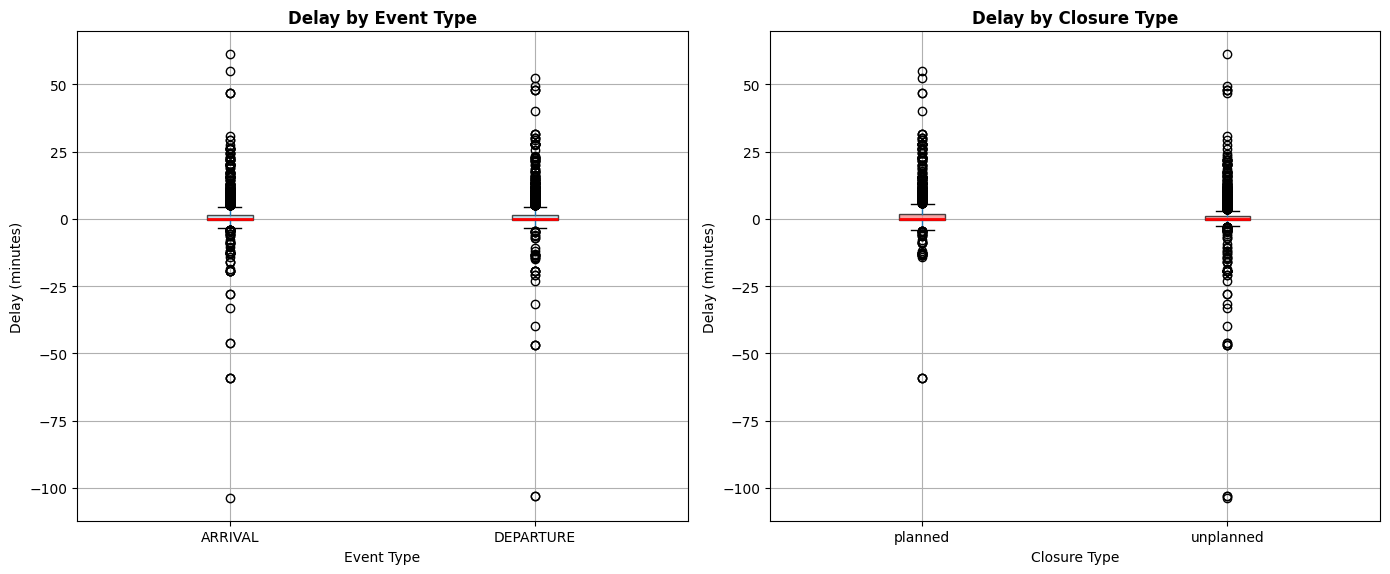


Mean delay by event type:
             mean  median    std  count
event_type                             
ARRIVAL     0.960     0.0  5.719   2685
DEPARTURE   1.066     0.0  5.794   2783

Mean delay by closure type:
               mean  median    std  count
closure_type                             
planned       1.551     0.0  5.570   2414
unplanned     0.589     0.0  5.866   3054


In [12]:
# Delay by categorical variables
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
filtered_df.boxplot(column="delay", by="event_type", ax=axes[0], patch_artist=True,
                    boxprops=dict(facecolor="lightblue", alpha=0.7),
                    medianprops=dict(color="red", linewidth=2))
axes[0].set_title("Delay by Event Type", fontweight="bold")
axes[0].set_xlabel("Event Type")
axes[0].set_ylabel("Delay (minutes)")
plt.suptitle("")

filtered_df.boxplot(column="delay", by="closure_type", ax=axes[1], patch_artist=True,
                    boxprops=dict(facecolor="lightcoral", alpha=0.7),
                    medianprops=dict(color="red", linewidth=2))
axes[1].set_title("Delay by Closure Type", fontweight="bold")
axes[1].set_xlabel("Closure Type")
axes[1].set_ylabel("Delay (minutes)")
plt.suptitle("")
plt.tight_layout()
plt.savefig("figures/eda_05/delay_by_categories.png", dpi=200, bbox_inches="tight")
plt.show()

print("\nMean delay by event type:")
print(filtered_df.groupby("event_type")["delay"].agg(["mean","median","std","count"]).round(3))
print("\nMean delay by closure type:")
print(filtered_df.groupby("closure_type")["delay"].agg(["mean","median","std","count"]).round(3))

## 6. Bivariate Relationships

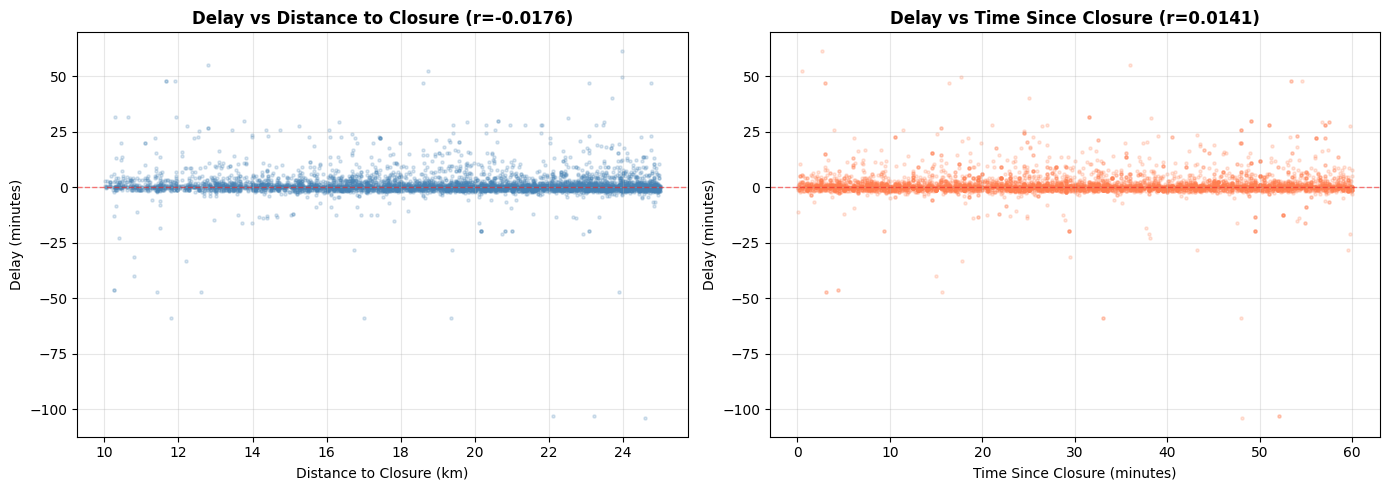

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, color, xlabel in [
    (axes[0], "distance_in_km", "steelblue", "Distance to Closure (km)"),
    (axes[1], "planned_time_diff", "coral", "Time Since Closure (minutes)")
]:
    ax.scatter(filtered_df[col], filtered_df["delay"],
               alpha=0.2, s=5, color=color)
    ax.axhline(0, color="red", linestyle="--", lw=1, alpha=0.5)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Delay (minutes)")
    corr = filtered_df[[col,"delay"]].corr().iloc[0,1]
    ax.set_title(f"Delay vs {xlabel.split('(')[0].strip()} (r={corr:.4f})", fontweight="bold")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/eda_05/scatter_delay_vs_predictors.png", dpi=200, bbox_inches="tight")
plt.show()

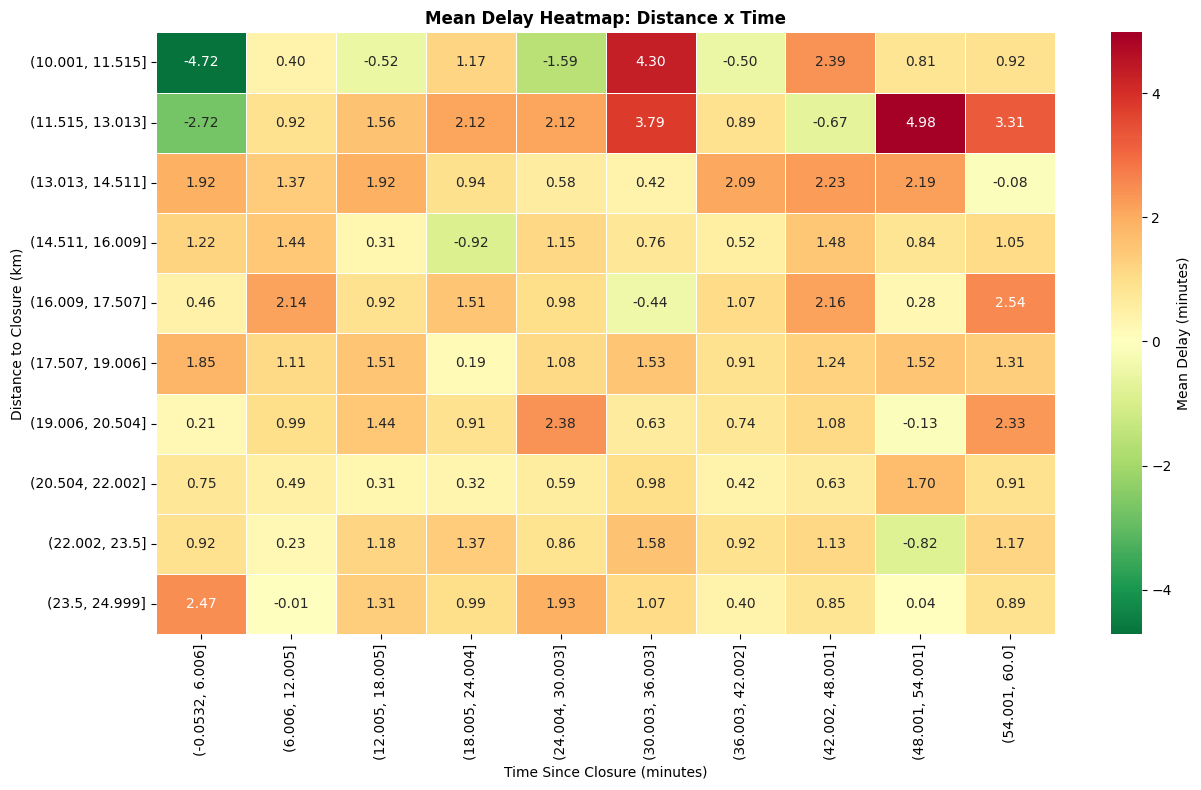

In [14]:
# Distance x time heatmap
hm = filtered_df.copy()
hm["dist_bin"] = pd.cut(hm["distance_in_km"], bins=10)
hm["time_bin"] = pd.cut(hm["planned_time_diff"], bins=10)
pivot = hm.pivot_table(values="delay", index="dist_bin", columns="time_bin", aggfunc="mean")

plt.figure(figsize=(13, 8))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn_r", center=0,
            cbar_kws={"label": "Mean Delay (minutes)"}, linewidths=0.5)
plt.xlabel("Time Since Closure (minutes)")
plt.ylabel("Distance to Closure (km)")
plt.title("Mean Delay Heatmap: Distance x Time", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/eda_05/heatmap_distance_time.png", dpi=200, bbox_inches="tight")
plt.show()

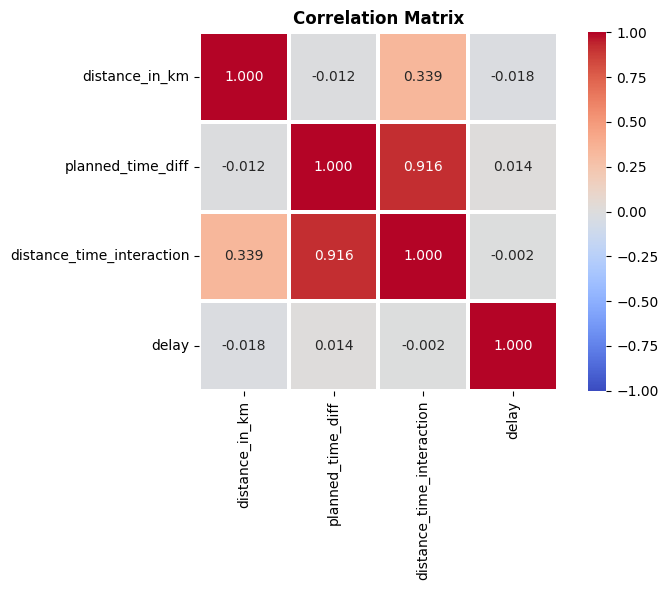


Correlation with delay:
distance_in_km              -0.017563
distance_time_interaction   -0.002304
planned_time_diff            0.014084
Name: delay, dtype: float64


In [15]:
# Correlation matrix
numeric_cols = ["distance_in_km", "planned_time_diff", "distance_time_interaction", "delay"]
corr_matrix = filtered_df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm", center=0,
            square=True, linewidths=1.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/eda_05/correlation_matrix.png", dpi=200, bbox_inches="tight")
plt.show()
print("\nCorrelation with delay:")
print(corr_matrix["delay"].drop("delay").sort_values())

## 7. Temporal Patterns

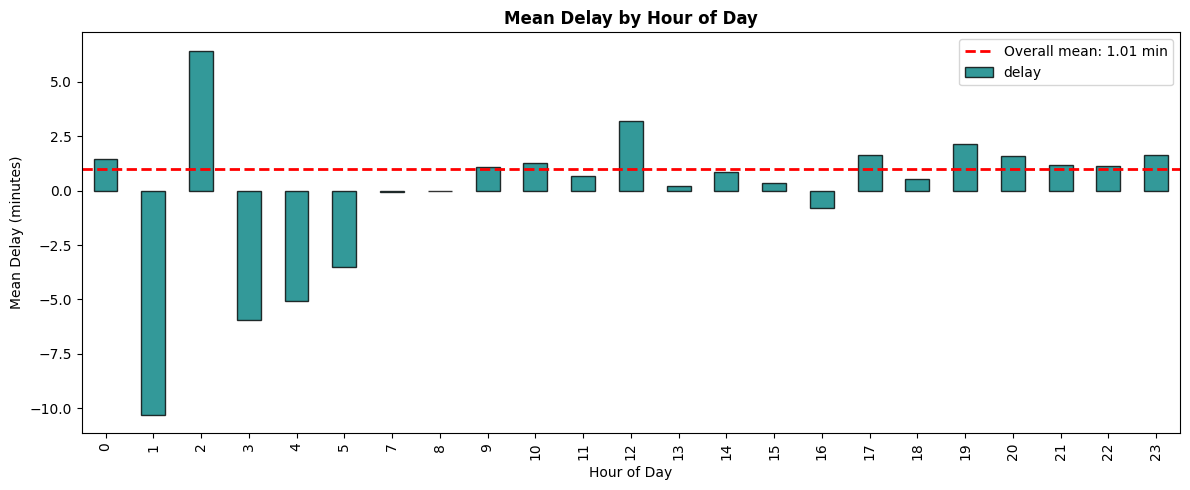

In [16]:
filtered_df["hour"] = filtered_df["planned_timestamp"].dt.hour
hourly = filtered_df.groupby("hour")["delay"].mean()

plt.figure(figsize=(12, 5))
hourly.plot(kind="bar", color="teal", edgecolor="black", alpha=0.8)
plt.xlabel("Hour of Day")
plt.ylabel("Mean Delay (minutes)")
plt.title("Mean Delay by Hour of Day", fontweight="bold")
plt.axhline(filtered_df["delay"].mean(), color="red", linestyle="--", lw=2,
            label=f"Overall mean: {filtered_df['delay'].mean():.2f} min")
plt.legend()
plt.tight_layout()
plt.savefig("figures/eda_05/delay_by_hour.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. Spatial Patterns

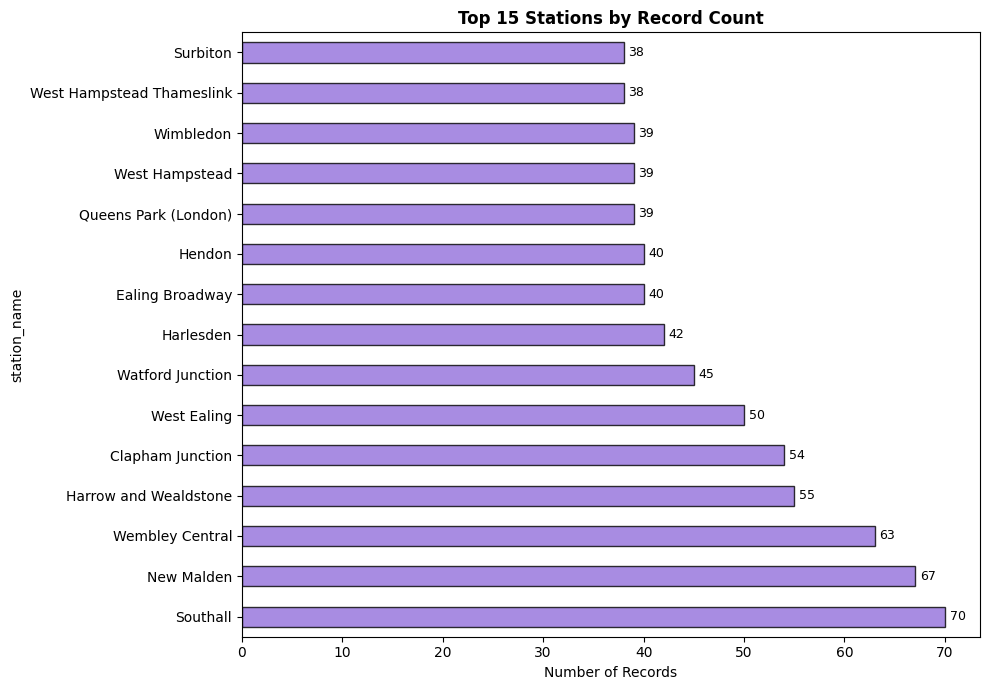

Top 15 stations: 719 rows (13.1% of total)


In [17]:
top_stations = filtered_df["station_name"].value_counts().head(15)
plt.figure(figsize=(10, 7))
top_stations.plot(kind="barh", color="mediumpurple", edgecolor="black", alpha=0.8)
plt.xlabel("Number of Records")
plt.title("Top 15 Stations by Record Count", fontweight="bold")
for i, v in enumerate(top_stations.values):
    plt.text(v + 0.5, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.savefig("figures/eda_05/top_stations.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Top 15 stations: {top_stations.sum():,} rows ({top_stations.sum()/len(filtered_df)*100:.1f}% of total)")

Unique closures: 125
Mean rows per closure:   43.7
Median rows per closure: 13.0
Max rows per closure:    334


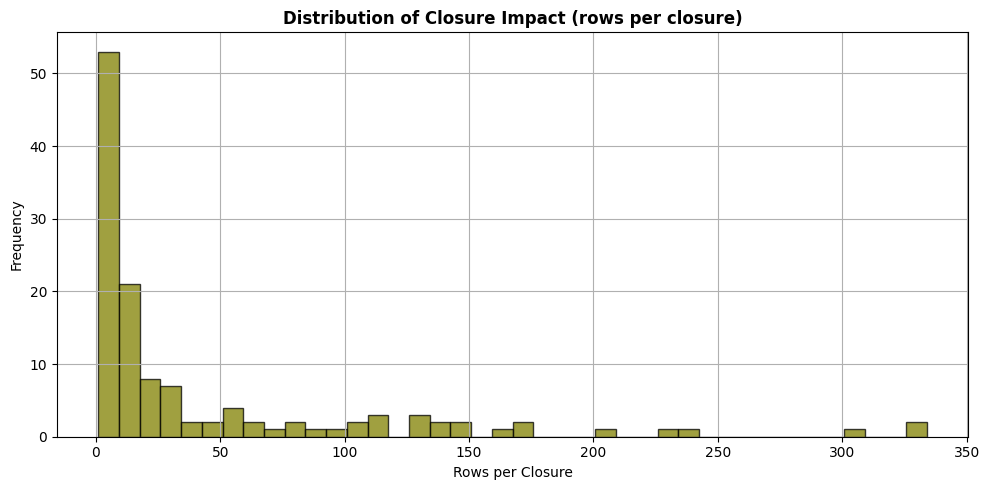

In [18]:
# Closure impact distribution
closure_counts = filtered_df.groupby("closure_id").size().sort_values(ascending=False)
print(f"Unique closures: {len(closure_counts)}")
print(f"Mean rows per closure:   {closure_counts.mean():.1f}")
print(f"Median rows per closure: {closure_counts.median():.1f}")
print(f"Max rows per closure:    {closure_counts.max()}")

plt.figure(figsize=(10, 5))
closure_counts.hist(bins=40, edgecolor="black", alpha=0.75, color="olive")
plt.xlabel("Rows per Closure")
plt.ylabel("Frequency")
plt.title("Distribution of Closure Impact (rows per closure)", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/eda_05/closure_impact.png", dpi=200, bbox_inches="tight")
plt.show()

## 9. Save Analytical Dataset

In [19]:
filtered_df.to_parquet("./data/processed/road_train_moments_dataset.parquet", index=False)
print(f"Saved road_train_moments dataset: {len(filtered_df):,} rows")
print("Path: data/processed/road_train_moments_dataset.parquet")
print()
print("Column summary:")
filtered_df.info()

Saved road_train_moments dataset: 5,468 rows
Path: data/processed/road_train_moments_dataset.parquet

Column summary:
<class 'pandas.DataFrame'>
Index: 5468 entries, 1382 to 539622
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   closure_id                 5468 non-null   str           
 1   closure_type               5468 non-null   str           
 2   closure_lat                5468 non-null   float64       
 3   closure_lon                5468 non-null   float64       
 4   validity_status            5468 non-null   str           
 5   cause_type                 5468 non-null   str           
 6   distance_in_km             5468 non-null   float64       
 7   station_name               5468 non-null   str           
 8   stanox                     5468 non-null   str           
 9   closure_start_time         5468 non-null   datetime64[us]
 10  actual_timestamp         